In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dữ liệu để notebook có thể chạy độc lập
df = pd.read_csv('../data/raw/healthcare-dataset-stroke-data.csv', delimiter=',', encoding='utf-8')
df = df.drop('id', axis=1)
df['bmi'] = df['bmi'].fillna(round(df['bmi'].median(), 2))
df = df[df['gender'] != 'Other']

## 2. Phan tich mo ta du lieu (EDA)
Notebook nay tap trung vao thong ke mo ta va truc quan hoa de rut ra cac mau hinh lien quan den dot quy.


### 2.1 Tong quan ty le dot quy
So sanh so luong nguoi bi dot quy va khong bi dot quy trong toan bo tap du lieu.


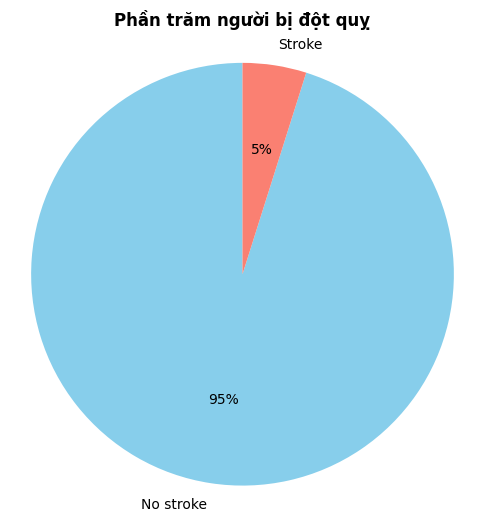

In [4]:
stroke_counts = df['stroke'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(stroke_counts,
        labels=['No stroke', 'Stroke'],
        autopct='%1.f%%',
        startangle=90,
        colors=['skyblue', 'salmon'])

plt.title('Phần trăm người bị đột quỵ', weight='bold', pad='13')
plt.axis('equal')
plt.show()

In [ ]:
df_stroke = df[df['stroke'] == 1]
df_no_stroke = df[df['stroke'] == 0]
print(f"Số lượng bệnh nhân đột quỵ: {len(df_stroke)}")
print(f"Số lượng bệnh nhân không đột quỵ: {len(df_no_stroke)}")

Số lượng bệnh nhân đột quỵ: 249
Số lượng bệnh nhân không đột quỵ: 4860


## 3. Phan tich rieng nhom benh nhan bi dot quy
Phan nay phan tich cac dac diem noi bat cua nhom benh nhan co nhan stroke = 1.


### 3.1 Phan bo do tuoi
Khao sat phan bo do tuoi de xac dinh nhom tuoi co nguy co cao.


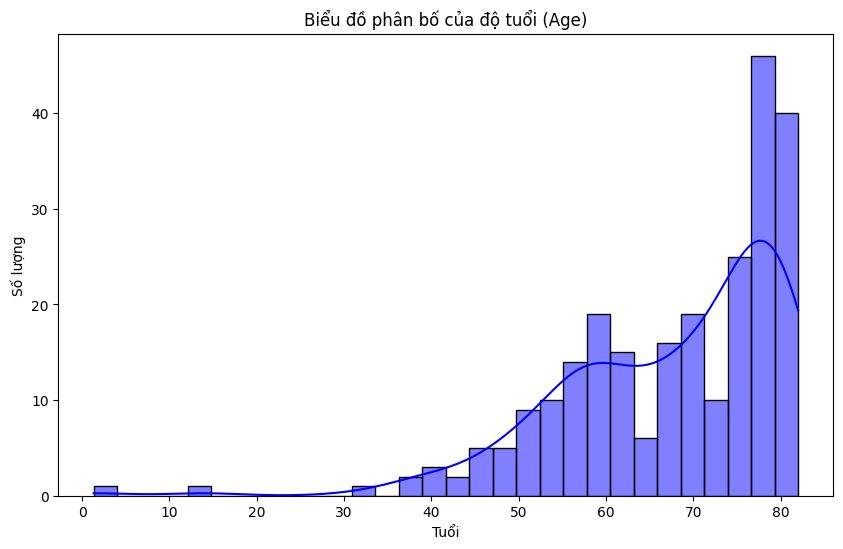

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_stroke['age'], kde=True, color='blue', bins=30)
plt.title('Biểu đồ phân bố của độ tuổi (Age)')
plt.xlabel('Tuổi')
plt.ylabel('Số lượng')
plt.show()

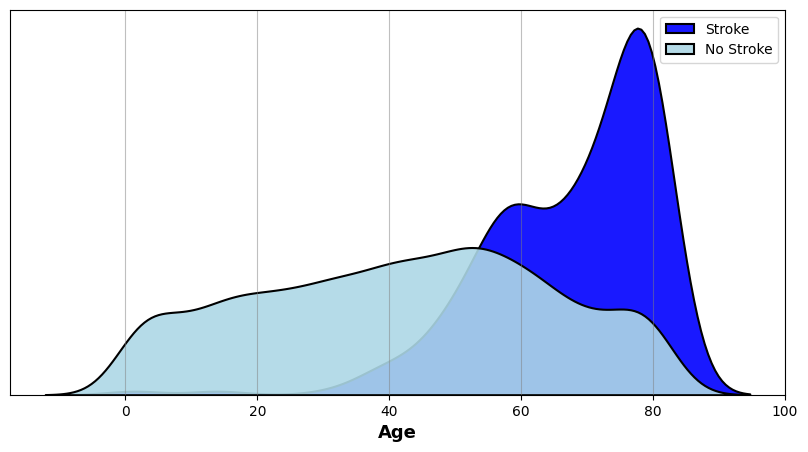

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(df_stroke['age'], ax=ax, color='blue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='Stroke')
sns.kdeplot(df_no_stroke['age'], ax=ax, color='lightblue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='No Stroke')

ax.set_xlabel('Age', fontsize=13, fontweight='bold')
ax.get_yaxis().set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.5)

plt.legend()
plt.show()

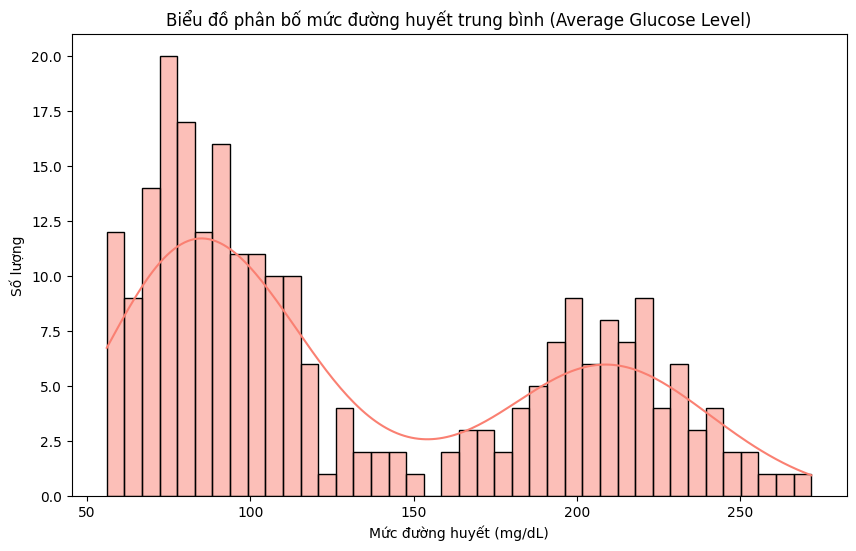

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_stroke['avg_glucose_level'], kde=True, color='salmon', bins=40)
plt.title('Biểu đồ phân bố mức đường huyết trung bình (Average Glucose Level)')
plt.xlabel('Mức đường huyết (mg/dL)')
plt.ylabel('Số lượng')
plt.show()

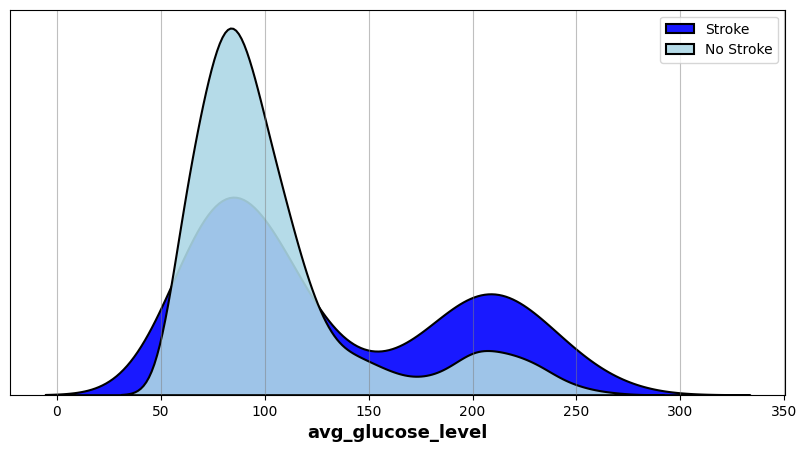

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(df_stroke['avg_glucose_level'], ax=ax, color='blue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='Stroke')
sns.kdeplot(df_no_stroke['avg_glucose_level'], ax=ax, color='lightblue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='No Stroke')

ax.set_xlabel('avg_glucose_level', fontsize=13, fontweight='bold')
ax.get_yaxis().set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.5)

plt.legend()
plt.show()

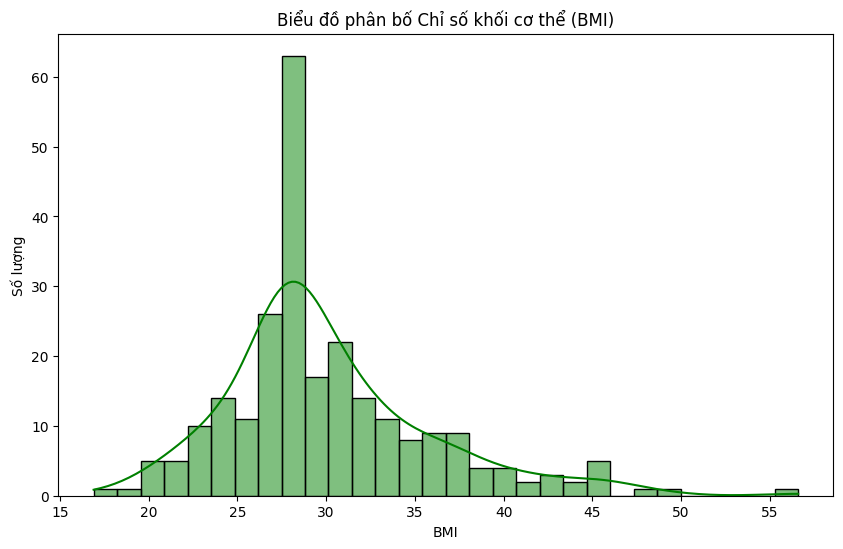

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df_stroke['bmi'], kde=True, color='green', bins=30)
plt.title('Biểu đồ phân bố Chỉ số khối cơ thể (BMI)')
plt.xlabel('BMI')
plt.ylabel('Số lượng')
plt.show()

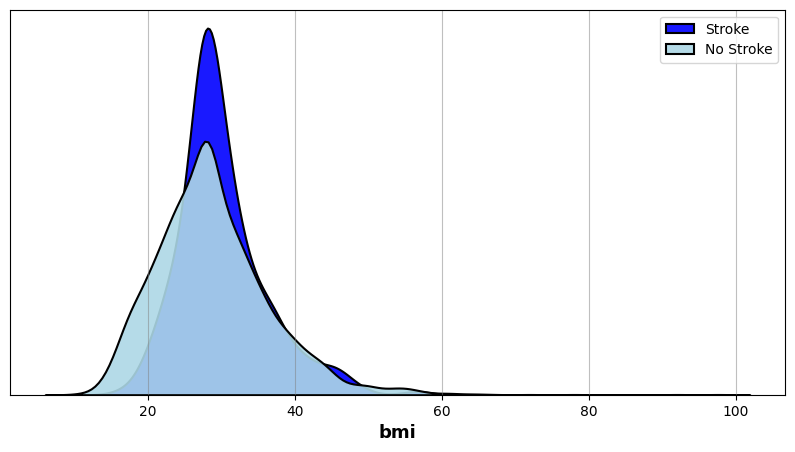

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(df_stroke['bmi'], ax=ax, color='blue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='Stroke')
sns.kdeplot(df_no_stroke['bmi'], ax=ax, color='lightblue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='No Stroke')

ax.set_xlabel('bmi', fontsize=13, fontweight='bold')
ax.get_yaxis().set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.5)

plt.legend()
plt.show()

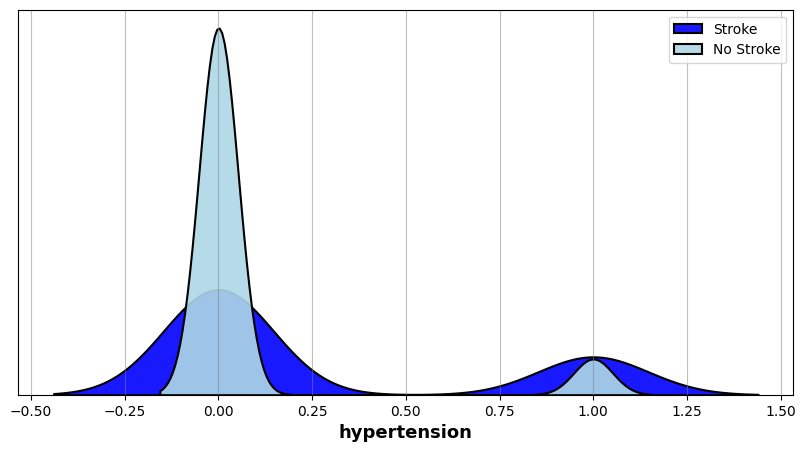

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.kdeplot(df_stroke['hypertension'], ax=ax, color='blue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='Stroke')
sns.kdeplot(df_no_stroke['hypertension'], ax=ax, color='lightblue', fill=True, alpha=0.9, linewidth=1.5, ec='black', label='No Stroke')

ax.set_xlabel('hypertension', fontsize=13, fontweight='bold')
ax.get_yaxis().set_visible(False)
ax.grid(axis='x', color='gray', alpha=0.5)

plt.legend()
plt.show()

In [ ]:
df['stroke_label'] = df['stroke'].map({0: 'No stroke', 1: 'Stroke'})

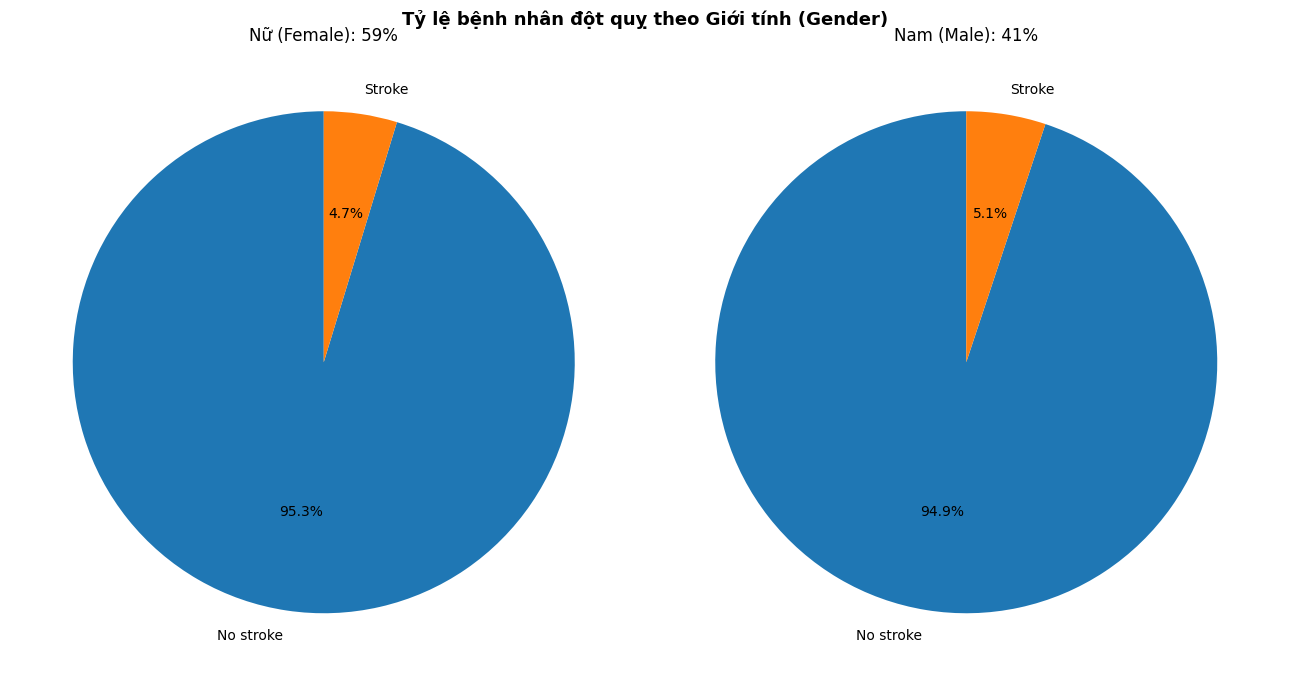

In [ ]:
female = df['gender'].value_counts().values[0]
male =  df['gender'].value_counts().values[1]

female_per = int(round(female/(female+male) * 100, 0))
male_per = int(round(male/(female+male)* 100, 0))

categories = sorted(df['gender'].unique())

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle('Tỷ lệ bệnh nhân đột quỵ theo Giới tính (Gender)', fontsize=13, fontweight='bold')

subset_female = df[df['gender'] == 'Female']['stroke_label'].value_counts()
axes[0].pie(subset_female, labels=subset_female.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Nữ (Female): {female_per}%')

subset_male = df[df['gender'] == 'Male']['stroke_label'].value_counts()
axes[1].pie(subset_male, labels=subset_male.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Nam (Male): {male_per}%')

plt.tight_layout()
plt.show()

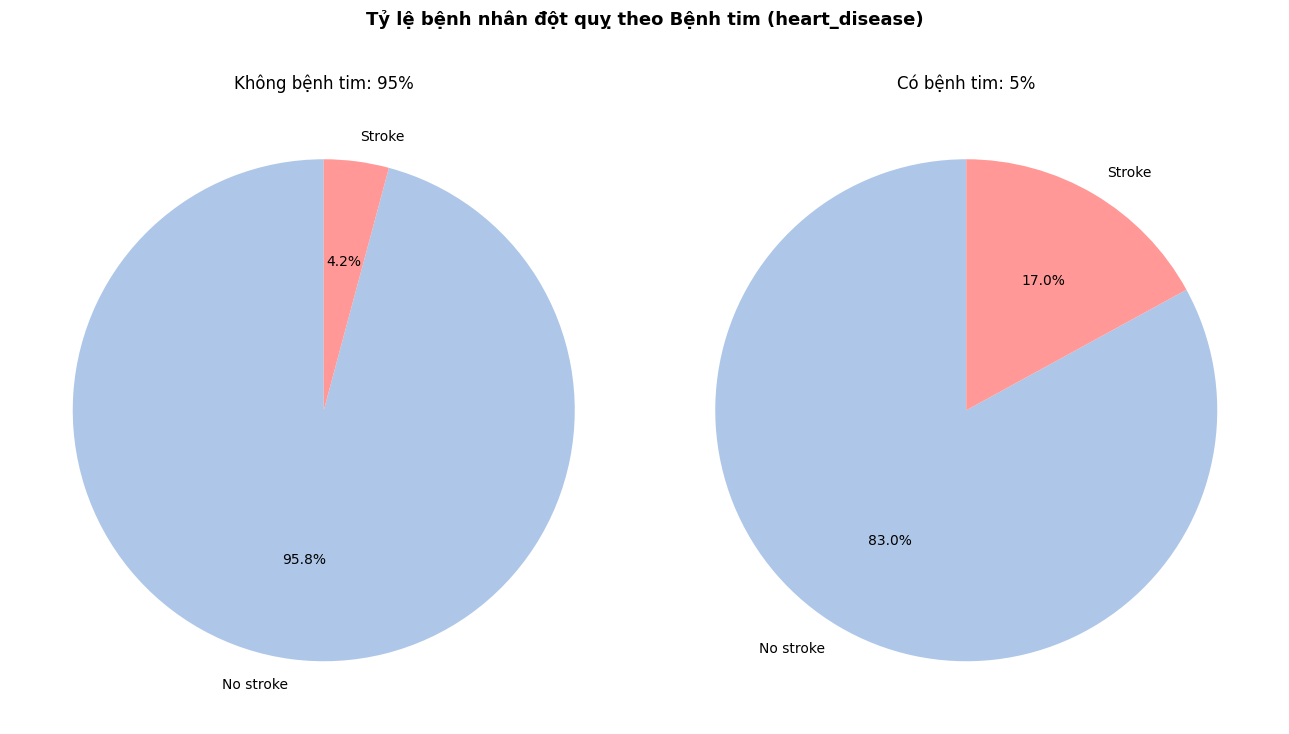

In [ ]:
hd_no = df['heart_disease'].value_counts()[0]
hd_yes = df['heart_disease'].value_counts()[1]
total = hd_no + hd_yes

hd_no_per = int(round(hd_no/total * 100, 0))
hd_yes_per = int(round(hd_yes/total * 100, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
fig.suptitle('Tỷ lệ bệnh nhân đột quỵ theo Bệnh tim (heart_disease)', fontsize=13, fontweight='bold')

subset_no = df[df['heart_disease'] == 0]['stroke_label'].value_counts()
axes[0].pie(subset_no, labels=subset_no.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])
axes[0].set_title(f'Không bệnh tim: {hd_no_per}%')

subset_yes = df[df['heart_disease'] == 1]['stroke_label'].value_counts()
axes[1].pie(subset_yes, labels=subset_yes.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])
axes[1].set_title(f'Có bệnh tim: {hd_yes_per}%')

plt.tight_layout()
plt.show()

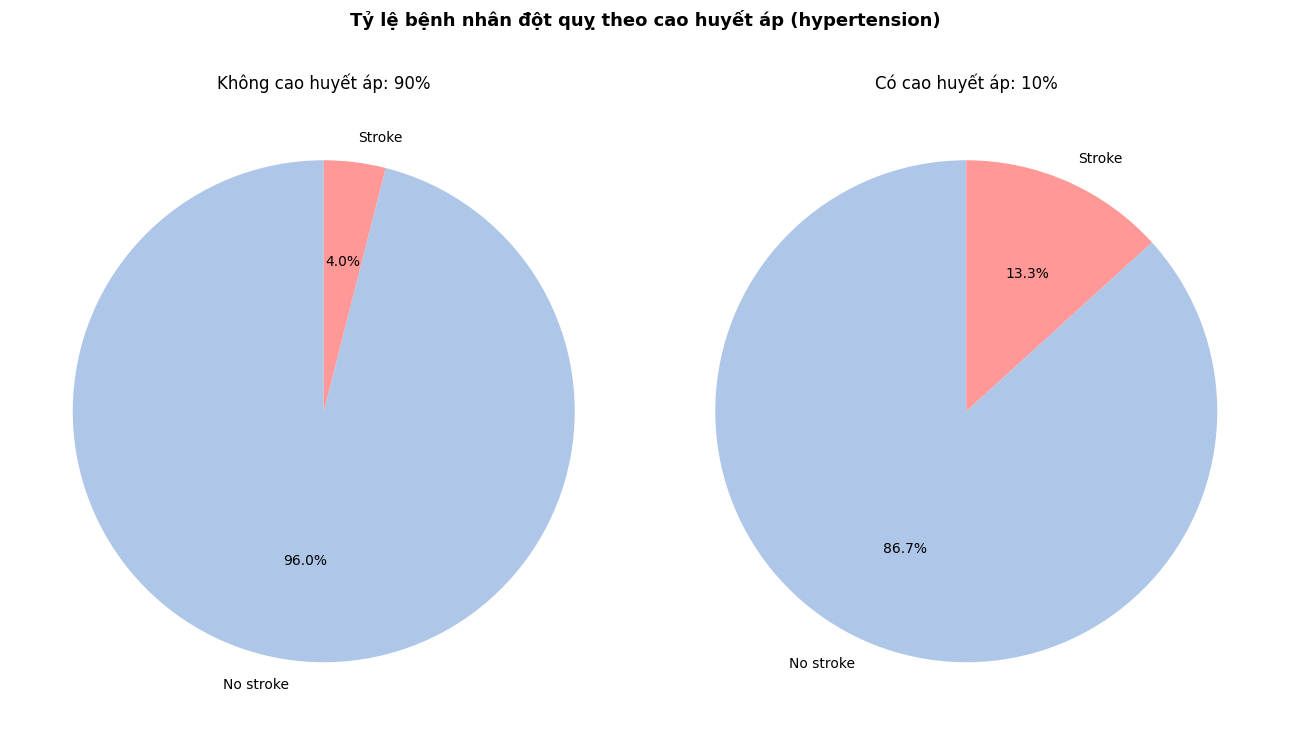

In [ ]:
ht_no = df['hypertension'].value_counts()[0]
ht_yes = df['hypertension'].value_counts()[1]
total = ht_no + ht_yes

ht_no_per = int(round(ht_no/total * 100, 0))
ht_yes_per = int(round(ht_yes/total * 100, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 8))
fig.suptitle('Tỷ lệ bệnh nhân đột quỵ theo cao huyết áp (hypertension)', fontsize=13, fontweight='bold')

subset_no_ht = df[df['hypertension'] == 0]['stroke_label'].value_counts()
axes[0].pie(subset_no_ht, labels=subset_no_ht.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])
axes[0].set_title(f'Không cao huyết áp: {ht_no_per}%')

subset_yes_ht = df[df['hypertension'] == 1]['stroke_label'].value_counts()
axes[1].pie(subset_yes_ht, labels=subset_yes_ht.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])
axes[1].set_title(f'Có cao huyết áp: {ht_yes_per}%')

plt.tight_layout()
plt.show()

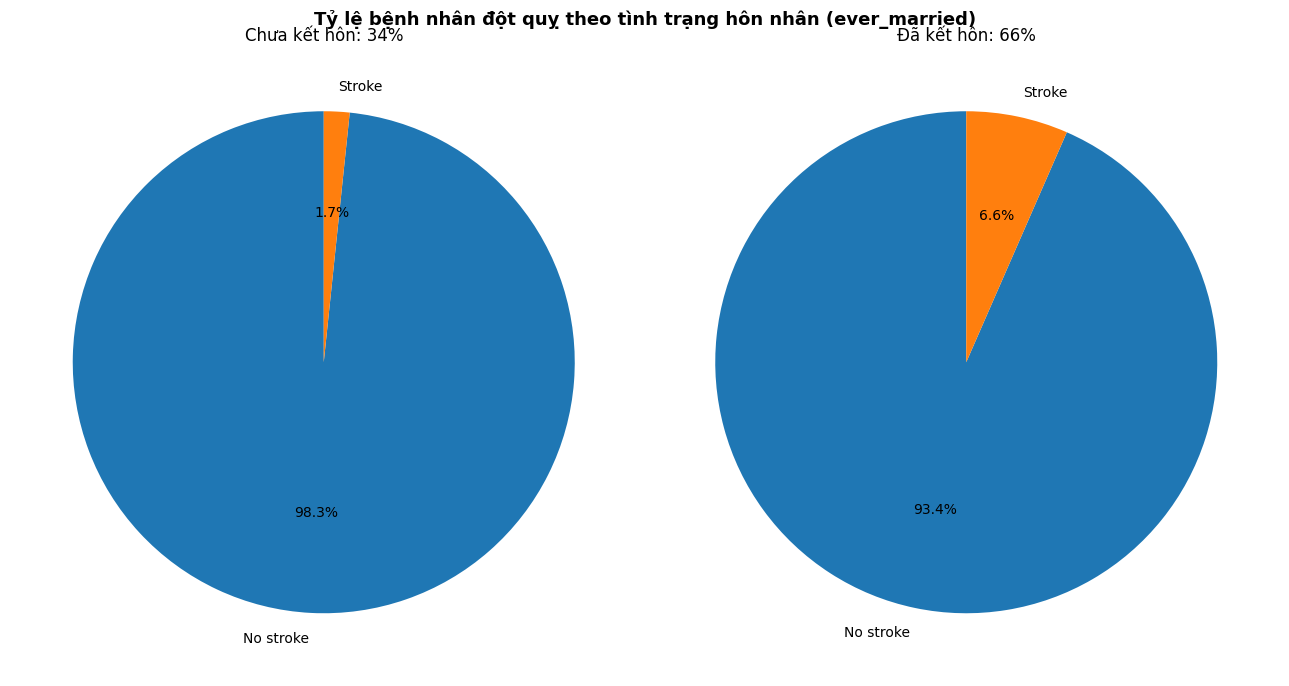

In [ ]:
categories = sorted(df['ever_married'].unique())

not_married = df['ever_married'].value_counts().values[0]
married =  df['ever_married'].value_counts().values[1]

not_married_per = int(round(married/(married+not_married) * 100, 0))
married_per = int(round(not_married/(married+not_married)* 100, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle('Tỷ lệ bệnh nhân đột quỵ theo tình trạng hôn nhân (ever_married)', fontsize=13, fontweight='bold')

subset_no = df[df['ever_married'] == 'No']['stroke_label'].value_counts()
axes[0].pie(subset_no, labels=subset_no.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Chưa kết hôn: {not_married_per}%')

subset_yes = df[df['ever_married'] == 'Yes']['stroke_label'].value_counts()
axes[1].pie(subset_yes, labels=subset_yes.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Đã kết hôn: {married_per}%')

plt.tight_layout()
plt.show()

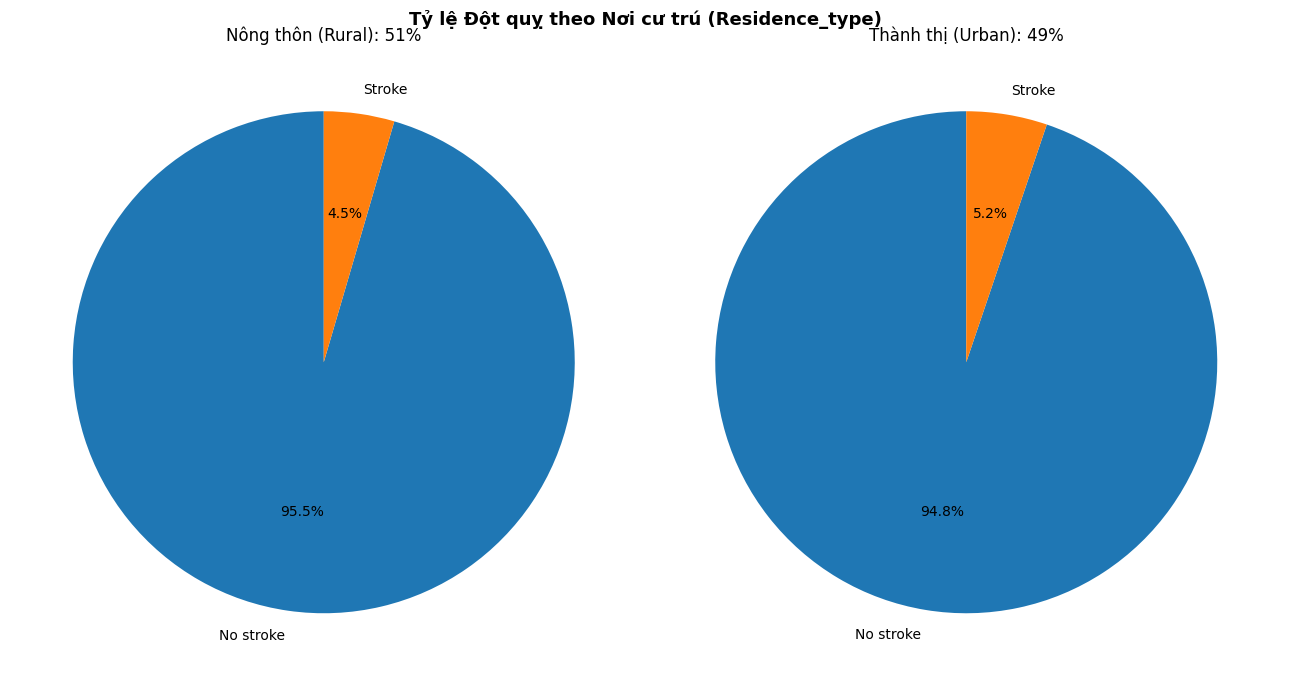

In [ ]:
categories = sorted(df['Residence_type'].unique())

urban = df['Residence_type'].value_counts().values[0]
rural =  df['Residence_type'].value_counts().values[1]

rural_per = int(round(rural/(rural+urban) * 100, 0))
urban_per = int(round(urban/(rural+urban)* 100, 0))

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
fig.suptitle('Tỷ lệ Đột quỵ theo Nơi cư trú (Residence_type)', fontsize=13, fontweight='bold')

subset_rural = df[df['Residence_type'] == 'Rural']['stroke_label'].value_counts()
axes[0].pie(subset_rural, labels=subset_rural.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title(f'Nông thôn (Rural): {urban_per}%')

subset_urban = df[df['Residence_type'] == 'Urban']['stroke_label'].value_counts()
axes[1].pie(subset_urban, labels=subset_urban.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Thành thị (Urban): {rural_per}%')

plt.tight_layout()
plt.show()

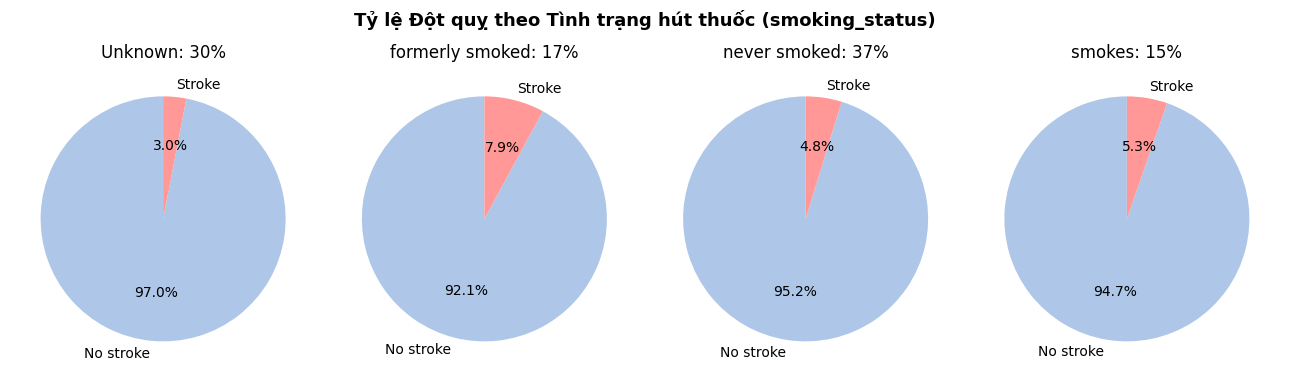

In [ ]:
categories = sorted(df['smoking_status'].unique())
total_samples = len(df)

fig, axes = plt.subplots(1, 4, figsize=(13, 4))
fig.suptitle('Tỷ lệ Đột quỵ theo Tình trạng hút thuốc (smoking_status)', fontsize=13, fontweight='bold')

for i, cat in enumerate(categories):
    count = len(df[df['smoking_status'] == cat])
    percent = int(round(count / total_samples * 100, 0))

    subset = df[df['smoking_status'] == cat]['stroke_label'].value_counts()

    axes[i].pie(subset, labels=subset.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])

    axes[i].set_title(f'{cat}: {percent}%')

plt.tight_layout()
plt.show()

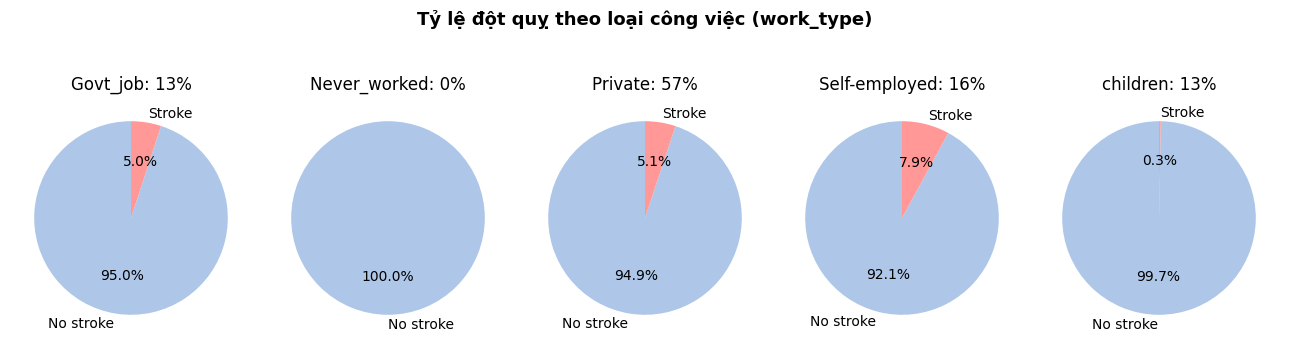

In [ ]:
categories = sorted(df['work_type'].unique())
total_samples = len(df)

fig, axes = plt.subplots(1, 5, figsize=(13, 4))
fig.suptitle('Tỷ lệ đột quỵ theo loại công việc (work_type)', fontsize=13, fontweight='bold')

for i, cat in enumerate(categories):
    count = len(df[df['work_type'] == cat])
    percent = int(round(count / total_samples * 100, 0))

    subset = df[df['work_type'] == cat]['stroke_label'].value_counts()

    axes[i].pie(subset, labels=subset.index, autopct='%1.1f%%', startangle=90, colors=['#aec7e8', '#ff9896'])

    axes[i].set_title(f'{cat}: {percent}%')

plt.tight_layout()
plt.show()

In [ ]:
filtered_data = df[(df['work_type'] == 'children') & (df['stroke'] == 1)]

count = len(filtered_data)
ages = filtered_data['age'].tolist()

print(f"Số lượng trẻ em bị đột quỵ (work_type='children' và stroke=1): {count}")
print(f"Độ tuổi: {ages}")

Số lượng trẻ em bị đột quỵ (work_type='children' và stroke=1): 2
Độ tuổi: [1.32, 14.0]


### 3.2 Gioi tinh va tinh trang hon nhan
Kiem tra su khac biet theo gioi tinh va tinh trang hon nhan trong nhom stroke.


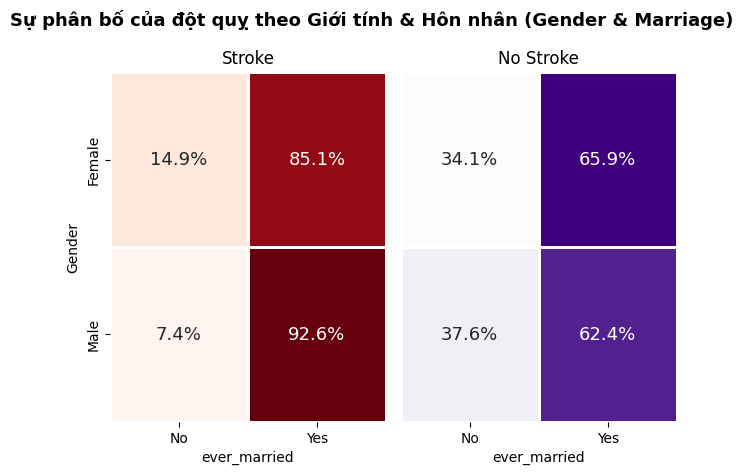

In [ ]:
stroke_ct = pd.crosstab(df_stroke['gender'], df_stroke['ever_married'], normalize='index')
no_stroke_ct = pd.crosstab(df_no_stroke['gender'], df_no_stroke['ever_married'], normalize='index')

fig, axes = plt.subplots(1, 2)
fig.suptitle('Sự phân bố của đột quỵ theo Giới tính & Hôn nhân (Gender & Marriage)', fontsize=13, fontweight='bold')

sns.heatmap(stroke_ct, annot=True, fmt='.1%', cmap='Reds', ax=axes[0],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[0].set_title('Stroke')
axes[0].set_ylabel('Gender')
axes[0].set_xlabel('ever_married')

sns.heatmap(no_stroke_ct, annot=True, fmt='.1%', cmap='Purples', ax=axes[1],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[1].set_title('No Stroke')
axes[1].set_ylabel('')
axes[1].set_yticks([])
axes[1].set_xlabel('ever_married')

plt.tight_layout()
plt.show()

### 3.3 Gioi tinh va tinh trang hut thuoc
Danh gia moi lien he giua gioi tinh va thoi quen hut thuoc trong nhom stroke.


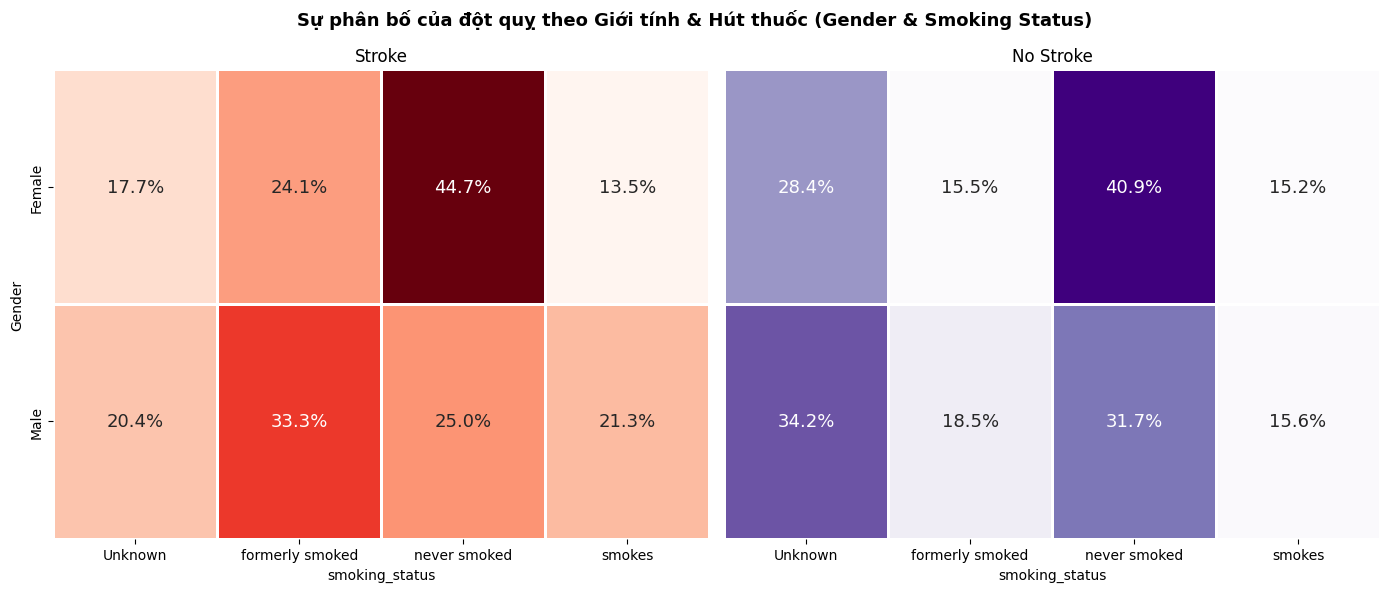

In [ ]:
stroke_ct_smoke = pd.crosstab(df_stroke['gender'], df_stroke['smoking_status'], normalize='index')
no_stroke_ct_smoke = pd.crosstab(df_no_stroke['gender'], df_no_stroke['smoking_status'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sự phân bố của đột quỵ theo Giới tính & Hút thuốc (Gender & Smoking Status)', fontsize=13, fontweight='bold')

sns.heatmap(stroke_ct_smoke, annot=True, fmt='.1%', cmap='Reds', ax=axes[0],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[0].set_title('Stroke')
axes[0].set_ylabel('Gender')
axes[0].set_xlabel('smoking_status')

sns.heatmap(no_stroke_ct_smoke, annot=True, fmt='.1%', cmap='Purples', ax=axes[1],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[1].set_title('No Stroke')
axes[1].set_ylabel('')
axes[1].set_yticks([])
axes[1].set_xlabel('smoking_status')

plt.tight_layout()
plt.show()

### 3.4 Cao huyet ap va benh tim
Phan tich su ket hop giua cao huyet ap, benh tim va nguy co dot quy.


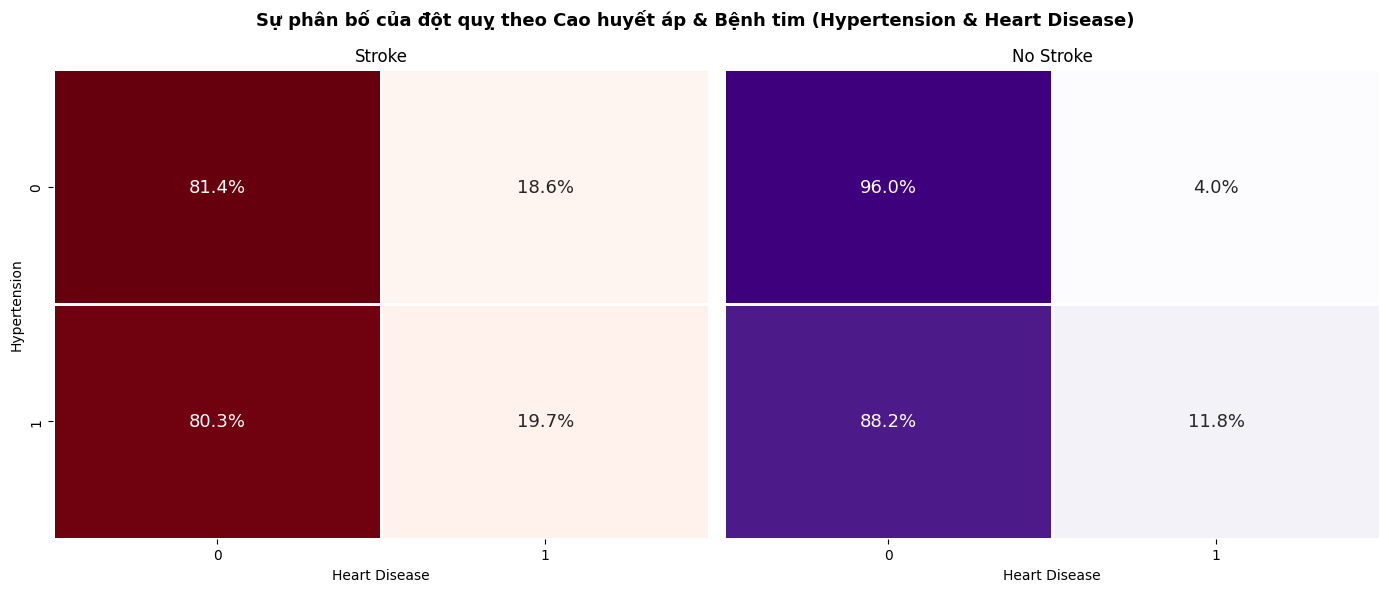

In [ ]:
stroke_ct_health = pd.crosstab(df_stroke['hypertension'], df_stroke['heart_disease'], normalize='index')
no_stroke_ct_health = pd.crosstab(df_no_stroke['hypertension'], df_no_stroke['heart_disease'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sự phân bố của đột quỵ theo Cao huyết áp & Bệnh tim (Hypertension & Heart Disease)', fontsize=13, fontweight='bold')

sns.heatmap(stroke_ct_health, annot=True, fmt='.1%', cmap='Reds', ax=axes[0],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[0].set_title('Stroke')
axes[0].set_ylabel('Hypertension')
axes[0].set_xlabel('Heart Disease')

sns.heatmap(no_stroke_ct_health, annot=True, fmt='.1%', cmap='Purples', ax=axes[1],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[1].set_title('No Stroke')
axes[1].set_ylabel('')
axes[1].set_yticks([])
axes[1].set_xlabel('Heart Disease')

plt.tight_layout()
plt.show()

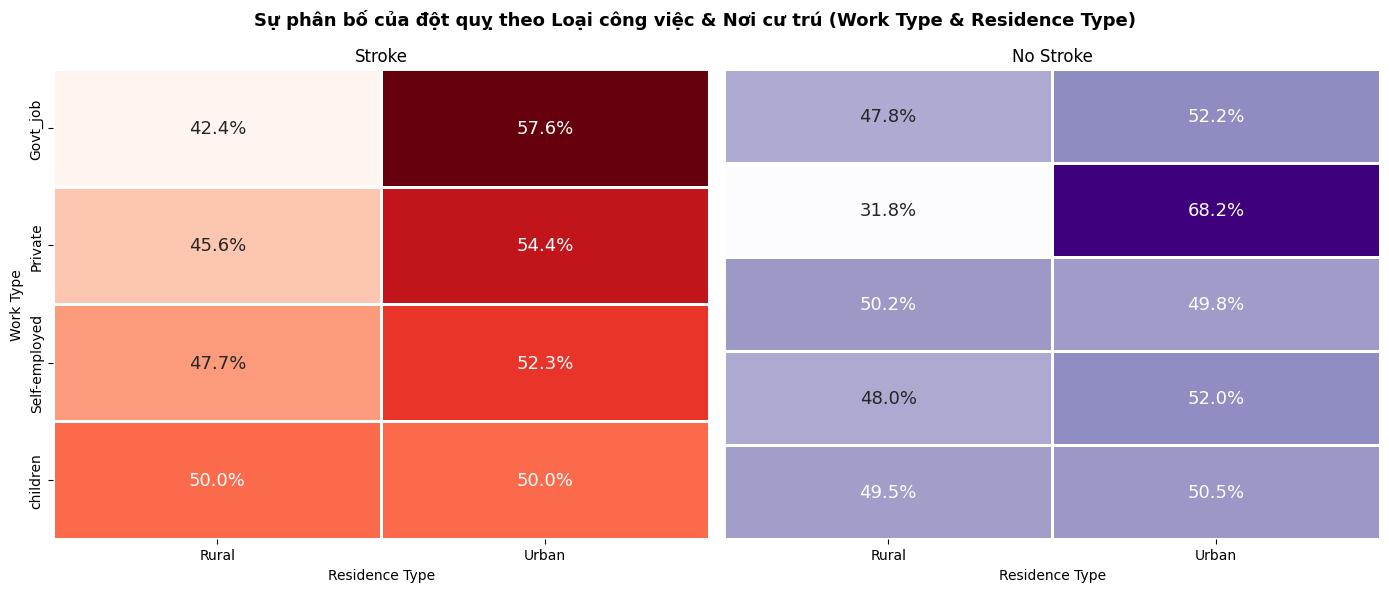

In [ ]:
stroke_ct_work_res = pd.crosstab(df_stroke['work_type'], df_stroke['Residence_type'], normalize='index')
no_stroke_ct_work_res = pd.crosstab(df_no_stroke['work_type'], df_no_stroke['Residence_type'], normalize='index')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Sự phân bố của đột quỵ theo Loại công việc & Nơi cư trú (Work Type & Residence Type)', fontsize=13, fontweight='bold')

sns.heatmap(stroke_ct_work_res, annot=True, fmt='.1%', cmap='Reds', ax=axes[0],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[0].set_title('Stroke')
axes[0].set_ylabel('Work Type')
axes[0].set_xlabel('Residence Type')

sns.heatmap(no_stroke_ct_work_res, annot=True, fmt='.1%', cmap='Purples', ax=axes[1],
            cbar=False, linewidths=1, annot_kws={"size": 13})
axes[1].set_title('No Stroke')
axes[1].set_ylabel('')
axes[1].set_yticks([])
axes[1].set_xlabel('Residence Type')

plt.tight_layout()
plt.show()

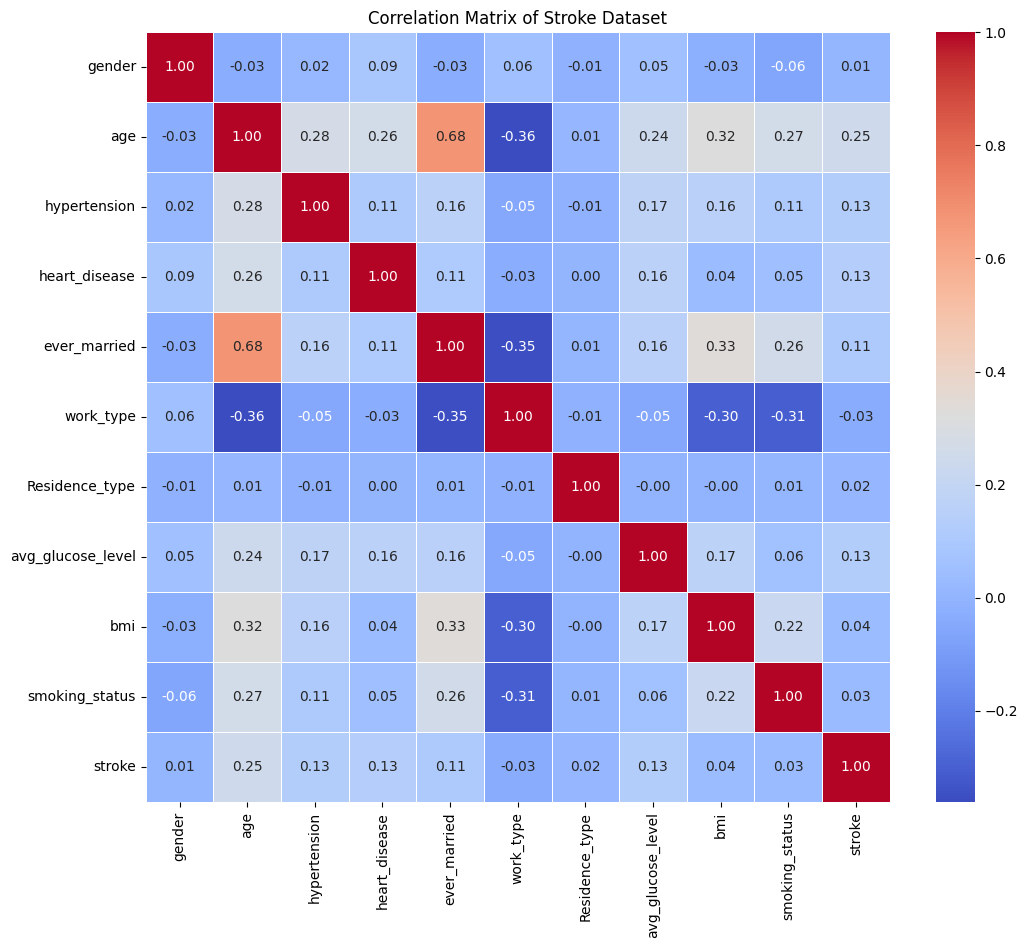

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# 3. Tính toán ma trận tương quan chỉ trên biến số
corr_matrix = df.select_dtypes(include='number').corr()

# 4. Vẽ biểu đồ nhiệt (Heatmap)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of Stroke Dataset')
plt.show()